# Phase 1 — Dataset Loading, Cleaning, and EDA
This notebook builds the **Phase 1 proposal evidence** for the mini‑project.

Goal (Phase 1): create a clean dataset and show measurable differences between **human** vs **LLM** emails.

Outputs you’ll reuse in the proposal:
- dataset size and class balance
- basic feature distributions (length, punctuation, URLs)
- a unified `text` field for later TF‑IDF models

In [1]:
import csv
import re
from pathlib import Path
import numpy as np
import pandas as pd

base_path = Path("../data/archive_data")

def _read_csv_safe(path: Path, *, engine="python", **kwargs) -> pd.DataFrame:
    return pd.read_csv(
        path,
        engine=engine,
        on_bad_lines="skip",
        **kwargs,
    )

def _repair_llm_phishing_csv(raw_csv_path: Path) -> pd.DataFrame:
    """Attempt to recover rows from a corrupted LLM phishing CSV.

    Expected schema: text,label
    Observed issues in this dataset file can include:
    - unescaped quotes / broken CSV quoting
    - multi-line records
    - multiple records concatenated into one physical line

    Heuristic used here: a record ends with `,0` or `,1` (label) followed by whitespace and then the next record starts.
    """
    raw = raw_csv_path.read_text(encoding="utf-8", errors="ignore")
    raw = raw.lstrip("\ufeff")  # strip BOM if present
    raw = raw.replace("\r\n", "\n").replace("\r", "\n")

    # Remove header if present
    raw_stripped = raw.lstrip()
    if raw_stripped.lower().startswith("text,label"):
        # drop first line only (header)
        parts = raw_stripped.split("\n", 1)
        raw_body = parts[1] if len(parts) == 2 else ""
    else:
        raw_body = raw_stripped

    # Normalize newlines/tabs to spaces, but keep the text content otherwise intact
    raw_body = raw_body.replace("\n", " ").replace("\t", " ")
    # Reduce runaway whitespace but keep at least 1 space as separator
    raw_body = re.sub(r"\s+", " ", raw_body).strip()

    # Separator between records: ',0' or ',1' followed by whitespace and then next token begins (often capital letter/quote)
    sep_iter = list(re.finditer(r",([01])(?=\s+[^\s])", raw_body))
    if not sep_iter:
        return pd.DataFrame(columns=["text", "label"])

    records: list[tuple[str, int]] = []
    start = 0
    for m in sep_iter:
        end = m.start()
        label = int(m.group(1))
        text = raw_body[start:end].strip()
        if text:
            records.append((text, label))
        start = m.end()
        # skip following whitespace
        while start < len(raw_body) and raw_body[start].isspace():
            start += 1

    # The loop above includes the final delimiter too; the remaining tail after the last delimiter is usually empty or a partial record.
    # If the tail still looks like it ends with a label, parse it as well.
    tail = raw_body[start:].strip()
    m_end = re.search(r"^(.*?),([01])\s*$", tail)
    if m_end:
        records.append((m_end.group(1).strip(), int(m_end.group(2))))

    df = pd.DataFrame(records, columns=["text", "label"])
    return df

def load_llm_phishing(raw_csv_path: Path) -> pd.DataFrame:
    # Try normal parsing first
    df_try = _read_csv_safe(
        raw_csv_path,
        sep=",",
        quoting=csv.QUOTE_NONE,
        dtype=str,
    )
    if {"text", "label"}.issubset(df_try.columns):
        df_try = df_try[["text", "label"]]
    else:
        df_try = pd.DataFrame(columns=["text", "label"])

    # Attempt heuristic repair and keep whichever yields more rows
    df_fixed = _repair_llm_phishing_csv(raw_csv_path)
    if len(df_fixed) > len(df_try):
        fixed_path = raw_csv_path.with_name("phishing_repaired.csv")
        df_fixed.to_csv(fixed_path, index=False, encoding="utf-8")
        print(f"[repair] raw parsed rows={len(df_try)}; repaired rows={len(df_fixed)} -> {fixed_path}")
        return df_fixed

    print(f"[repair] raw parsed rows={len(df_try)}; repaired rows={len(df_fixed)} (kept raw)")
    return df_try

# --- Load raw datasets ---
# Human-generated: sender, receiver, date, subject, body, urls, label
human_legit = _read_csv_safe(base_path / "human-generated" / "legit.csv")
human_phish = _read_csv_safe(base_path / "human-generated" / "phishing.csv")

# LLM-generated: legit is standard; phishing may be corrupted
llm_legit = _read_csv_safe(base_path / "llm-generated" / "legit.csv")
llm_phish = load_llm_phishing(base_path / "llm-generated" / "phishing.csv")

# --- Add metadata labels ---
for df in (human_legit, human_phish):
    df["source"] = "human"
for df in (llm_legit, llm_phish):
    df["source"] = "llm"

human_legit["is_phishing"] = 0
human_phish["is_phishing"] = 1
llm_legit["is_phishing"] = 0
llm_phish["is_phishing"] = 1

# --- Standardize schema ---
def standardize(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Human files already have subject/body; LLM files usually only have 'text'
    if "text" in df.columns and "body" not in df.columns:
        df["subject"] = ""
        df["body"] = df["text"]
    else:
        df["subject"] = df.get("subject", "")
        df["body"] = df.get("body", "")

    df["subject"] = df["subject"].fillna("").astype(str)
    df["body"] = df["body"].fillna("").astype(str)

    # Unified text field used for feature analysis + later ML
    df["text"] = (df["subject"].str.strip() + "\n\n" + df["body"].str.strip()).str.strip()

    # URL count: prefer provided 'urls' column if present, otherwise infer from regex
    url_regex = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
    if "urls" in df.columns:
        df["url_count"] = pd.to_numeric(df["urls"], errors="coerce").fillna(0).astype(int)
    else:
        df["url_count"] = df["text"].apply(lambda s: len(url_regex.findall(s)))

    df["is_llm"] = (df["source"] == "llm").astype(int)
    return df[["text", "subject", "body", "source", "is_llm", "is_phishing", "url_count"]]

human_legit_s = standardize(human_legit)
human_phish_s = standardize(human_phish)
llm_legit_s = standardize(llm_legit)
llm_phish_s = standardize(llm_phish)

df_all = pd.concat([human_legit_s, human_phish_s, llm_legit_s, llm_phish_s], ignore_index=True)

print("Dataset shape:", df_all.shape)
print("Source balance:\n", df_all["source"].value_counts())
print("Phishing balance:\n", df_all["is_phishing"].value_counts())
df_all.head(3)

[repair] raw parsed rows=595; repaired rows=1000 -> ..\data\archive_data\llm-generated\phishing_repaired.csv
Dataset shape: (4000, 7)
Source balance:
 source
human    2000
llm      2000
Name: count, dtype: int64
Phishing balance:
 is_phishing
0    2000
1    2000
Name: count, dtype: int64


,text,subject,body,source,is_llm,is_phishing,url_count
0,Starting IC with wizard\n\nHi\r\n\r\n\t\tI am ...,Starting IC with wizard,Hi\r\n\r\n\t\tI am running the IR test program...,human,0,0,0
1,Trade Me -- A question on your auction: Auctio...,Trade Me -- A question on your auction: Auctio...,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r...,human,0,0,0
2,Trade Me - A request from a Trade Me member. A...,Trade Me - A request from a Trade Me member. A...,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nTrade ...,human,0,0,0


In [2]:
# Optional: inspect the raw LLM phishing CSV for malformed lines (debug only)
raw_path = base_path / "llm-generated" / "phishing.csv"
with open(raw_path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

print("Raw file line count:", len(lines))
print("First 10 lines (truncated):")
for i in range(min(10, len(lines))):
    print(lines[i][:160].replace("\n", "\\n"))

Raw file line count: 1001
First 10 lines (truncated):
text,label\n
Dear User, We have received reports indicating that your account has been flagged for suspicious activities. To ensure the safety of your account and prevent an
Dear Sarah Thompson, I hope this email finds you in good health. My name is Jessica Wilson, and I'm a senior recruiter at Global Solutions. We recently came acr
Dear Michael, I hope this email finds you well. I am Laura Thompson, the Head of Security at our esteemed financial institution. We have recently detected some 
Dear Sarah, I am Daniel Anderson, the Security Manager at our esteemed financial institution. We have recently detected some unusual activities on your account 
Dear John, I hope this email finds you well. As an authorized IRS agent, I would like to inform you about an important tax refund that you are eligible for. Our
Dear Sarah, I hope this email finds you well. As an IRS officer responsible for tax refunds, I am writing to inform you about an

,char_len,word_count,avg_word_len,ttr,exclaim_count,question_count,url_count
source,,,,,,,
human,2679.16,340.28,6.42,0.63,1.42,1.95,0.69
llm,650.14,99.04,5.61,0.77,0.44,0.03,0.90


is_phishing,0,1
source,,
human,1000,1000
llm,1000,1000


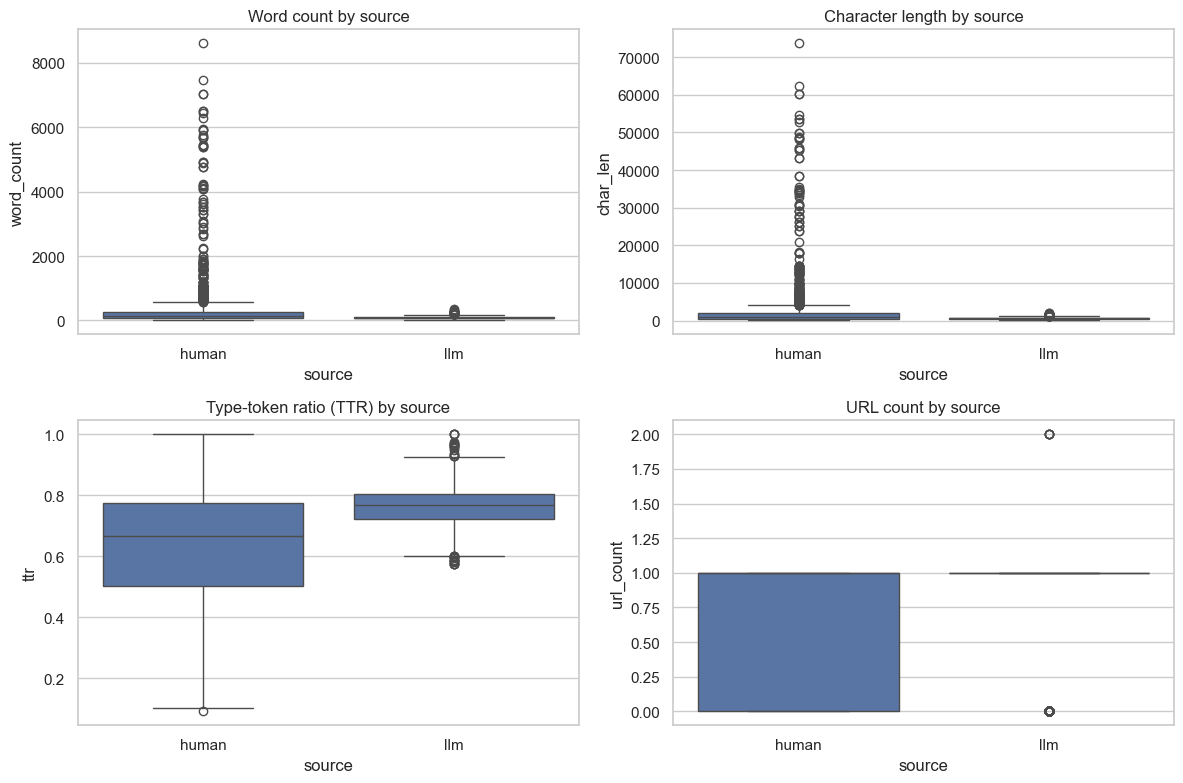

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Feature engineering for Phase 1 EDA ---
def add_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    txt = df["text"].fillna("").astype(str)
    df["char_len"] = txt.str.len()
    df["word_count"] = txt.str.split().apply(len)
    df["avg_word_len"] = txt.apply(lambda s: (sum(len(w) for w in s.split()) / max(len(s.split()), 1)))
    df["exclaim_count"] = txt.str.count("!")
    df["question_count"] = txt.str.count("\\?")
    df["ttr"] = txt.apply(lambda s: (len(set(s.lower().split())) / max(len(s.split()), 1)))
    return df

df_feat = add_eda_features(df_all)

# --- Summary tables ---
display(df_feat.groupby("source")[["char_len", "word_count", "avg_word_len", "ttr", "exclaim_count", "question_count", "url_count"]].mean().round(2))
display(pd.crosstab(df_feat["source"], df_feat["is_phishing"], rownames=["source"], colnames=["is_phishing"]))

# --- Simple plots (Phase 1 evidence) ---
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(data=df_feat, x="source", y="word_count", ax=axes[0, 0])
axes[0, 0].set_title("Word count by source")

sns.boxplot(data=df_feat, x="source", y="char_len", ax=axes[0, 1])
axes[0, 1].set_title("Character length by source")

sns.boxplot(data=df_feat, x="source", y="ttr", ax=axes[1, 0])
axes[1, 0].set_title("Type-token ratio (TTR) by source")

sns.boxplot(data=df_feat, x="source", y="url_count", ax=axes[1, 1])
axes[1, 1].set_title("URL count by source")

plt.tight_layout()
plt.show()

## Quick interpretation (for your proposal)
- Human emails are **much longer and more variable** (threads/quoted text/boilerplate), creating extreme outliers.
- LLM emails are **shorter and more consistent** in this dataset, so we report **medians/IQR** and also use **log-scale** plots for fair comparison.
- URL-related features are **zero-inflated**, so proportions (has URL) are more informative than raw counts alone.

,median,q25,q75,median,q25,q75,median,q25,q75,median,...,q75,median,q25,q75,median,q25,q75,median,q25,q75
source,,,,,,,,,,,,,,,,,,,,,
human,968.0,513.5,1998.25,131.5,69.0,268.0,5.73,5.20,6.54,0.67,...,0.78,0.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,1.0
llm,596.5,490.0,764.00,90.0,74.0,118.0,5.60,5.35,5.84,0.77,...,0.81,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0


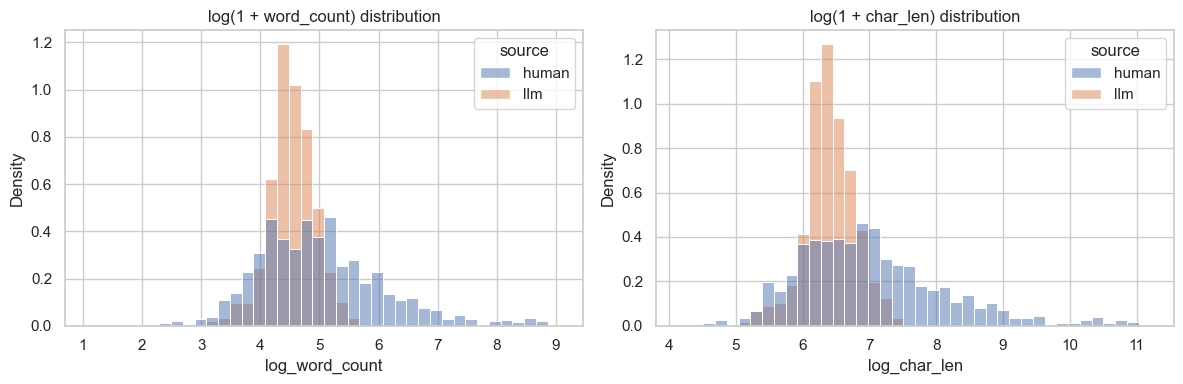

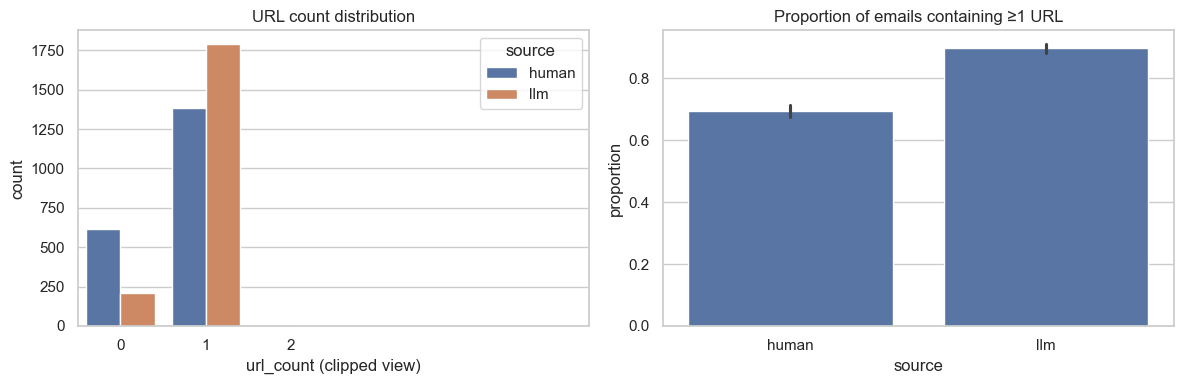

Saved figures to: C:\EIE4121_Miniproject\results


In [4]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Robust summary (median + IQR) to reduce the effect of extreme outliers
cols = ["char_len", "word_count", "avg_word_len", "ttr", "exclaim_count", "question_count", "url_count"]
summary = (
    df_feat.groupby("source")[cols]
    .agg(["median", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
    .round(2)
)
summary.columns = ["median", "q25", "q75"] * len(cols)
display(summary)

# Log-scale distributions for heavy-tailed length features
df_plot = df_feat.copy()
df_plot["log_word_count"] = np.log1p(df_plot["word_count"])
df_plot["log_char_len"] = np.log1p(df_plot["char_len"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_plot, x="log_word_count", hue="source", bins=40, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("log(1 + word_count) distribution")
sns.histplot(data=df_plot, x="log_char_len", hue="source", bins=40, stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("log(1 + char_len) distribution")
plt.tight_layout()
fig_path = results_dir / "phase1_length_distributions_log.png"
plt.savefig(fig_path, dpi=200)
plt.show()

# URL count distribution (zero-inflated)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df_feat, x="url_count", hue="source", ax=axes[0])
axes[0].set_title("URL count distribution")
axes[0].set_xlim(-0.5, 5.5)  # focus on small counts
axes[0].set_xlabel("url_count (clipped view)")

df_feat["has_url"] = (df_feat["url_count"] > 0).astype(int)
sns.barplot(data=df_feat, x="source", y="has_url", ax=axes[1])
axes[1].set_title("Proportion of emails containing ≥1 URL")
axes[1].set_ylabel("proportion")
plt.tight_layout()
fig_path = results_dir / "phase1_url_features.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figures to:", results_dir.resolve())

## Deeper “class differences”: phishing vs legit within each source
Phase 1 asks for differences **among classes**. Besides the main comparison (**human vs LLM**), we also examine:
- phishing vs legit **within human-only**
- phishing vs legit **within LLM-only**

This helps show whether the dataset contains class-specific artifacts (e.g., URL patterns) that may affect model generalization.

char_len  word_count  avg_word_len   ttr  exclaim_count  \
source phish_label                                                            
human  legit         4168.34      523.16          6.16  0.64           2.30   
       phishing      1189.99      157.41          6.68  0.63           0.55   
llm    legit          642.88       96.76          5.68  0.77           0.37   
       phishing       657.40      101.32          5.54  0.77           0.50   

                    question_count  url_count  
source phish_label                             
human  legit                  2.66       0.43  
       phishing               1.24       0.95  
llm    legit                  0.03       0.94  
       phishing               0.02       0.86

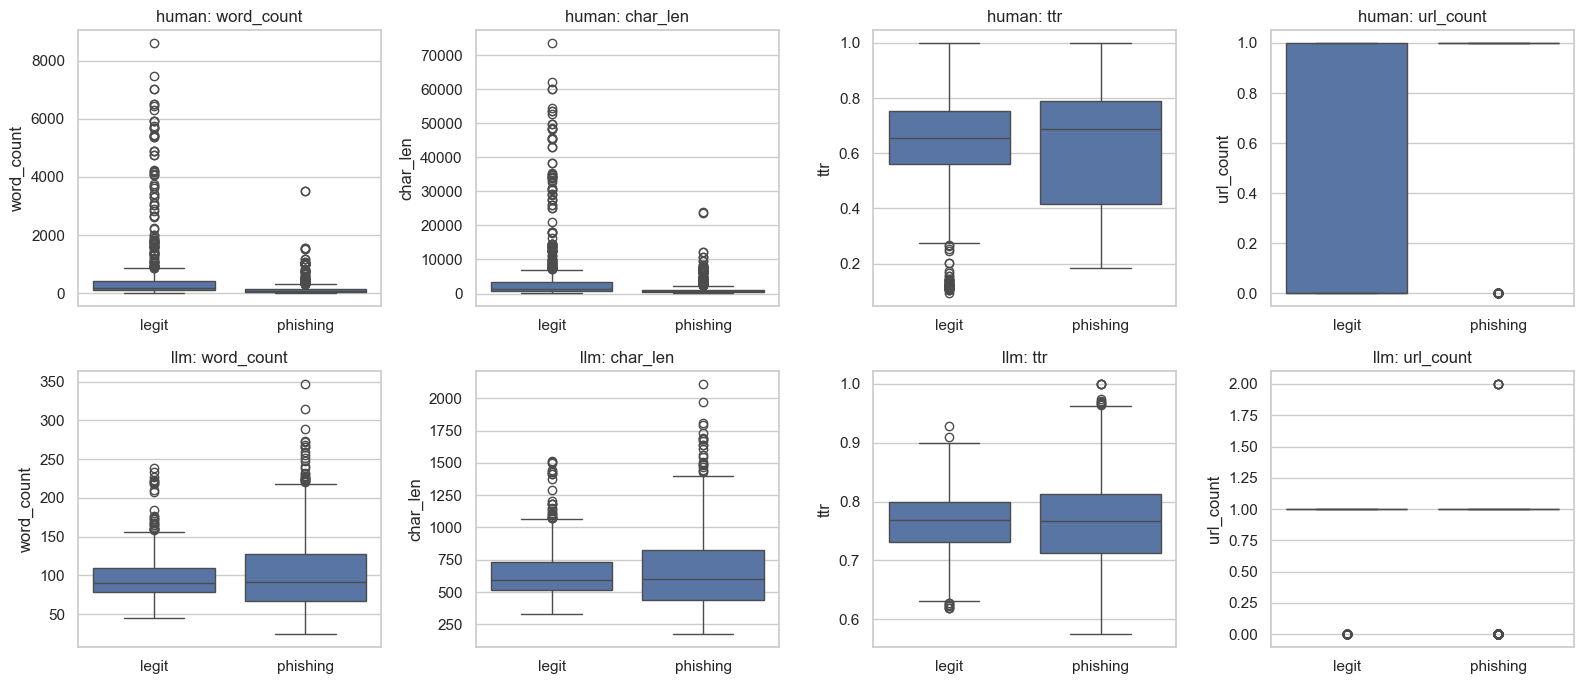

prop_has_url
source phish_label              
human  legit               0.433
       phishing            0.952
llm    legit               0.936
       phishing            0.856

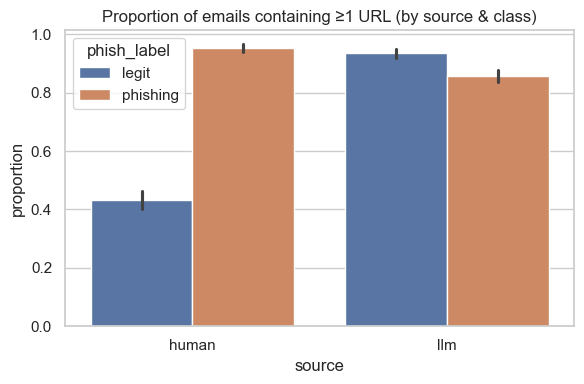

Saved figures: C:\EIE4121_Miniproject\results\phase1_within_source_boxplots.png
Saved figures: C:\EIE4121_Miniproject\results\phase1_within_source_has_url.png


In [7]:
# Compare phishing vs legit within each source using the engineered features
df_cls = df_feat.copy()
df_cls["phish_label"] = df_cls["is_phishing"].map({0: "legit", 1: "phishing"})

# Summary table: mean feature values per (source, phishing)
feat_cols = ["char_len", "word_count", "avg_word_len", "ttr", "exclaim_count", "question_count", "url_count"]
display(
    df_cls.groupby(["source", "phish_label"])[feat_cols]
    .mean()
    .round(2)
    .sort_index()
)

# Visual: within-source comparisons (boxplots)
sns.set_theme(style="whitegrid")
plot_cols = ["word_count", "char_len", "ttr", "url_count"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
for r, src in enumerate(["human", "llm"]):
    sub = df_cls[df_cls["source"] == src]
    for c, col in enumerate(plot_cols):
        ax = axes[r, c]
        sns.boxplot(data=sub, x="phish_label", y=col, ax=ax)
        ax.set_title(f"{src}: {col}")
        ax.set_xlabel("")
plt.tight_layout()
box_path = results_dir / "phase1_within_source_boxplots.png"
plt.savefig(box_path, dpi=200)
plt.show()

# URL presence (binary) is often more stable than raw counts
df_cls["has_url"] = (df_cls["url_count"] > 0).astype(int)
display(
    df_cls.groupby(["source", "phish_label"])["has_url"]
    .mean()
    .rename("prop_has_url")
    .to_frame()
    .round(3)
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df_cls, x="source", y="has_url", hue="phish_label", ax=ax)
ax.set_title("Proportion of emails containing ≥1 URL (by source & class)")
ax.set_ylabel("proportion")
plt.tight_layout()
url_path = results_dir / "phase1_within_source_has_url.png"
plt.savefig(url_path, dpi=200)
plt.show()

print("Saved figures:", box_path.resolve())
print("Saved figures:", url_path.resolve())

### Optional: baseline phishing detection within each source
This is not the main task, but it strengthens the Phase 1 “differences among classes” requirement by checking whether phishing vs legit is separable *within* human and *within* LLM emails.

In [8]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import json

def train_eval_phishing_within(df_sub: pd.DataFrame, *, source_name: str):
    X_sub = df_sub["text"].fillna("").astype(str)
    y_sub = df_sub["is_phishing"].astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    res = {}
    for model_name, base_model in models.items():
        local_model = clone(base_model)
        local_model.fit(X_tr, y_tr)
        y_pred = local_model.predict(X_te)
        res[model_name] = {
            "accuracy": float(accuracy_score(y_te, y_pred)),
            "precision": float(precision_score(y_te, y_pred, zero_division=0)),
            "recall": float(recall_score(y_te, y_pred, zero_division=0)),
            "f1": float(f1_score(y_te, y_pred, zero_division=0)),
        }

    print(f"\n[phishing-within-{source_name}] n={len(df_sub)} (train={len(X_tr)}, test={len(X_te)})")
    for k, v in res.items():
        print(k, v)
    return res

phish_within_results = {
    "human": train_eval_phishing_within(df_all[df_all["source"] == "human"], source_name="human"),
    "llm": train_eval_phishing_within(df_all[df_all["source"] == "llm"], source_name="llm"),
}

out_path = results_dir / "phishing_within_source_metrics.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(phish_within_results, f, indent=2)
print("Saved:", out_path.resolve())


[phishing-within-human] n=2000 (train=1600, test=400)
logreg {'accuracy': 0.9975, 'precision': 1.0, 'recall': 0.995, 'f1': 0.9974937343358395}
linear_svm {'accuracy': 0.9975, 'precision': 1.0, 'recall': 0.995, 'f1': 0.9974937343358395}

[phishing-within-llm] n=2000 (train=1600, test=400)
logreg {'accuracy': 0.995, 'precision': 0.9900990099009901, 'recall': 1.0, 'f1': 0.9950248756218906}
linear_svm {'accuracy': 0.995, 'precision': 0.9900990099009901, 'recall': 1.0, 'f1': 0.9950248756218906}
Saved: C:\EIE4121_Miniproject\results\phishing_within_source_metrics.json


## Baseline text classifiers (start of Phase 2)
We train two baseline models to classify **human vs LLM** using TF‑IDF features:
- Logistic Regression (interpretable baseline)
- Linear SVM (often strong for text)

We keep the split stratified and fix a random seed for reproducibility.


=== logreg ===
Metrics(accuracy=0.99875, precision=1.0, recall=0.9975, f1=0.9987484355444305)
              precision    recall  f1-score   support

       human       1.00      1.00      1.00       400
         llm       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



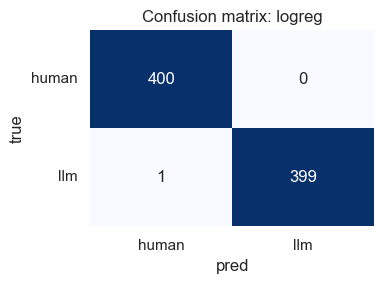


=== linear_svm ===
Metrics(accuracy=1.0, precision=1.0, recall=1.0, f1=1.0)
              precision    recall  f1-score   support

       human       1.00      1.00      1.00       400
         llm       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



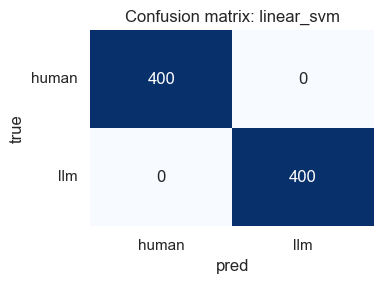

Saved: C:\EIE4121_Miniproject\results\baseline_metrics.json


In [5]:
from dataclasses import asdict, dataclass
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
 )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

results_dir = Path("..") / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Target for the primary task (Phase 1/2): human vs llm
X = df_all["text"].fillna("").astype(str)
y = df_all["is_llm"].astype(int)  # 1=llm, 0=human

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
 )

models = {
    "logreg": Pipeline([
        ("tfidf", tfidf),
        ("clf", LogisticRegression(max_iter=2000, n_jobs=None)),
    ]),
    "linear_svm": Pipeline([
        ("tfidf", tfidf),
        ("clf", LinearSVC()),
    ]),
}

@dataclass
class Metrics:
    accuracy: float
    precision: float
    recall: float
    f1: float

def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    return (
        Metrics(
            accuracy=float(accuracy_score(y_te, y_pred)),
            precision=float(precision_score(y_te, y_pred, zero_division=0)),
            recall=float(recall_score(y_te, y_pred, zero_division=0)),
            f1=float(f1_score(y_te, y_pred, zero_division=0)),
        ),
        y_pred,
    )

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    m, y_pred = evaluate(model, X_test, y_test)
    results[name] = asdict(m)
    print("\n===", name, "===")
    print(m)
    print(classification_report(y_test, y_pred, target_names=["human", "llm"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_xticklabels(["human", "llm"])
    ax.set_yticklabels(["human", "llm"], rotation=0)
    ax.set_title(f"Confusion matrix: {name}")
    plt.tight_layout()
    plt.savefig(results_dir / f"cm_{name}.png", dpi=200)
    plt.show()

# Save metrics summary for the report
with open(results_dir / "baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print("Saved:", (results_dir / "baseline_metrics.json").resolve())

## Stronger validation (beyond “single split”)
Because baseline accuracy is extremely high, we add sanity checks to estimate whether performance might be inflated by dataset artifacts or leakage.

Checks included:
- $k$-fold cross-validation (more stable estimate)
- exact-duplicate overlap between train and test (direct leakage risk)
- near-duplicate leakage check using character n-gram TF‑IDF + nearest neighbors
- length-controlled breakdown: accuracy across word-count bins

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import NearestNeighbors
import json

# 1) k-fold cross-validation for human vs LLM task
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results[name] = {
        "accuracy_mean": float(scores.mean()),
        "accuracy_std": float(scores.std()),
        "n_splits": int(cv.get_n_splits()),
    }
print("Cross-validation (accuracy):")
for k, v in cv_results.items():
    print(k, v)

# 2) Exact duplicate overlap between train and test (simple leakage indicator)
def _normalize_text(s: str) -> str:
    s = (s or "").lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_norm = X_train.apply(_normalize_text)
test_norm = X_test.apply(_normalize_text)
train_set = set(train_norm.tolist())
test_set = set(test_norm.tolist())
exact_overlap = train_set.intersection(test_set)
dup_stats = {
    "train_unique": int(len(train_set)),
    "test_unique": int(len(test_set)),
    "exact_overlap_unique": int(len(exact_overlap)),
    "exact_overlap_frac_test_unique": float(len(exact_overlap) / max(len(test_set), 1)),
}
print("\nExact train/test overlap (normalized text):", dup_stats)

# 3) Near-duplicate leakage check (test -> nearest neighbor in train)
# Use character n-grams to capture small edits/reformatting.
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 6), min_df=2)
Xtr_char = char_vec.fit_transform(X_train)
Xte_char = char_vec.transform(X_test)

nn = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute")
nn.fit(Xtr_char)
dist, _ = nn.kneighbors(Xte_char, return_distance=True)
sim = 1.0 - dist.ravel()

# Threshold: very high similarity suggests near-duplicate content.
thr = 0.98
near_dup_count = int((sim >= thr).sum())
near_dup_stats = {
    "threshold": float(thr),
    "near_duplicate_test_count": near_dup_count,
    "near_duplicate_test_frac": float(near_dup_count / max(X_test.shape[0], 1)),
    "similarity_p95": float(np.quantile(sim, 0.95)),
    "similarity_p99": float(np.quantile(sim, 0.99)),
}
print("\nNear-duplicate (test->train) stats:", near_dup_stats)

# 4) Length-controlled breakdown (accuracy across word-count bins in the test set)
meta = df_feat.loc[X.index, ["word_count", "source", "is_llm", "is_phishing"]].copy()
meta["split"] = "train"
meta.loc[X_test.index, "split"] = "test"
meta_test = meta[meta["split"] == "test"].copy()
meta_test["len_bin"] = pd.qcut(meta_test["word_count"], q=5, duplicates="drop")

length_bin_results = {}
for name, model in models.items():
    # Reuse the already-fit baseline models from the earlier cell
    y_pred_te = model.predict(X_test)
    tmp = meta_test.copy()
    tmp["y_true"] = y_test.values
    tmp["y_pred"] = y_pred_te
    # avoid pandas FutureWarnings by applying on a selected column
    acc_by_bin = tmp.groupby("len_bin", observed=False)[["y_true", "y_pred"]].apply(
        lambda g: float((g["y_true"] == g["y_pred"]).mean())
    )
    length_bin_results[name] = {"acc_by_bin": {str(k): float(v) for k, v in acc_by_bin.items()}}
    print(f"\nAccuracy by test length bin ({name}):")
    display(acc_by_bin)

# Save validation summary for reporting
validation_out = {
    "cross_validation": cv_results,
    "exact_duplicate_overlap": dup_stats,
    "near_duplicate_test_to_train": near_dup_stats,
    "length_bin_results": length_bin_results,
}
val_path = results_dir / "baseline_validation.json"
with open(val_path, "w", encoding="utf-8") as f:
    json.dump(validation_out, f, indent=2)
print("\nSaved:", val_path.resolve())

Cross-validation (accuracy):
logreg {'accuracy_mean': 0.99925, 'accuracy_std': 0.0015000000000000124, 'n_splits': 5}
linear_svm {'accuracy_mean': 0.99925, 'accuracy_std': 0.0009999999999999786, 'n_splits': 5}

Exact train/test overlap (normalized text): {'train_unique': 2691, 'test_unique': 761, 'exact_overlap_unique': 252, 'exact_overlap_frac_test_unique': 0.3311432325886991}

Near-duplicate (test->train) stats: {'threshold': 0.98, 'near_duplicate_test_count': 268, 'near_duplicate_test_frac': 0.335, 'similarity_p95': 1.0, 'similarity_p99': 1.0}

Accuracy by test length bin (logreg):


len_bin
(1.999, 69.0]      1.000000
(69.0, 88.6]       0.993464
(88.6, 119.0]      1.000000
(119.0, 175.0]     1.000000
(175.0, 6446.0]    1.000000
dtype: float64


Accuracy by test length bin (linear_svm):


len_bin
(1.999, 69.0]      1.0
(69.0, 88.6]       1.0
(88.6, 119.0]      1.0
(119.0, 175.0]     1.0
(175.0, 6446.0]    1.0
dtype: float64


Saved: C:\EIE4121_Miniproject\results\baseline_validation.json


## Leakage-resistant evaluation (step-by-step)


Your baseline results are extremely high. This section tests whether that performance holds up under stricter evaluation designed to reduce **duplicate / near-duplicate leakage** and **topic shortcuts**.



We do three checks, one-by-one:



1. **Exact de-dup before split** (remove identical normalized texts)

2. **Near-duplicate grouping + GroupKFold** (ensure near-duplicates stay in the same fold)

3. **Source-aware stress tests** (train on legit only → test on phishing only, and vice versa)



All outputs are exported to `results/` so they can be cited in the report.

### Step 1 — Exact de-dup before train/test split


Goal: remove **exact duplicate** emails (after light normalization) *before* splitting, so the test set is less likely to contain the same template text as training.



This is the simplest leakage control and usually drops inflated scores if duplicates were driving performance.

In [6]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split

results_dir = Path("..") / "results"
results_dir.mkdir(parents=True, exist_ok=True)

def _normalize_text_for_dedup(s: str) -> str:
    s = (s or "").lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Build a de-duplicated dataset of unique normalized texts
X_full = df_all["text"].fillna("").astype(str)
y_full = df_all["is_llm"].astype(int)

norm_full = X_full.apply(_normalize_text_for_dedup)
dedup_df = pd.DataFrame({"text": X_full.values, "y": y_full.values, "norm": norm_full.values})
dedup_df = dedup_df.drop_duplicates(subset=["norm"], keep="first").reset_index(drop=True)

X_dedup = dedup_df["text"].astype(str)
y_dedup = dedup_df["y"].astype(int)

print("Original N:", len(X_full), "| After exact dedup N:", len(X_dedup))
print("Class balance (LLM=1) after dedup:")
display(y_dedup.value_counts(normalize=True))

# Split AFTER dedup
X_tr, X_te, y_tr, y_te = train_test_split(
    X_dedup, y_dedup,
    test_size=0.2,
    random_state=42,
    stratify=y_dedup,
)

dedup_metrics = {}
for name, model in models.items():
    m = clone(model)
    m.fit(X_tr, y_tr)
    met, _ = evaluate(m, X_te, y_te)
    dedup_metrics[name] = {
        "accuracy": float(met.accuracy),
        "precision": float(met.precision),
        "recall": float(met.recall),
        "f1": float(met.f1),
    }
    print("\n[exact-dedup split]", name, dedup_metrics[name])

out_path = results_dir / "leakage_resistant_exact_dedup.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump({
        "n_original": int(len(X_full)),
        "n_after_exact_dedup": int(len(X_dedup)),
        "metrics": dedup_metrics,
    }, f, indent=2)
print("Saved:", out_path.resolve())

Original N: 4000 | After exact dedup N: 3200
Class balance (LLM=1) after dedup:


y
1    0.624375
0    0.375625
Name: proportion, dtype: float64


[exact-dedup split] logreg {'accuracy': 0.9984375, 'precision': 0.9975062344139651, 'recall': 1.0, 'f1': 0.9987515605493134}

[exact-dedup split] linear_svm {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
Saved: C:\EIE4121_Miniproject\results\leakage_resistant_exact_dedup.json


### Step 2 — Near-duplicate grouping + GroupKFold


Goal: even after exact de-duplication, many emails can still be *near-duplicates* (templates with small edits).


We build **near-duplicate groups** using character n-gram TF‑IDF + kNN cosine similarity, then evaluate with **GroupKFold** so that near-duplicates cannot appear in both train and test.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import NearestNeighbors

def _union_find(n: int):
    parent = np.arange(n)
    rank = np.zeros(n, dtype=int)
    def find(a: int) -> int:
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a
    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1
    return find, union, parent

# Use the exact-dedup dataset from Step 1 (X_dedup, y_dedup)
X_norm = X_dedup.apply(_normalize_text_for_dedup)

# Character n-gram TF-IDF captures small edits / reformatting
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 6), min_df=2)
X_char = char_vec.fit_transform(X_norm)

# kNN search to avoid O(n^2) all-pairs comparisons
k = 8  # small neighbor list is usually enough for template families
nn = NearestNeighbors(n_neighbors=min(k, X_char.shape[0]), metric="cosine", algorithm="brute")
nn.fit(X_char)
dist, idx = nn.kneighbors(X_char, return_distance=True)
sim = 1.0 - dist

thr = 0.98
find, union, parent = _union_find(len(X_norm))

# Connect i with neighbors above similarity threshold (excluding self)
for i in range(len(X_norm)):
    for j_pos in range(1, idx.shape[1]):
        j = int(idx[i, j_pos])
        if sim[i, j_pos] >= thr:
            union(i, j)

roots = np.array([find(i) for i in range(len(X_norm))])
_, group_ids = np.unique(roots, return_inverse=True)
group_ids = group_ids.astype(int)

# Some group stats
unique_groups, group_sizes = np.unique(group_ids, return_counts=True)
print("Near-duplicate grouping stats:")
print("  N samples:", len(X_norm))
print("  N groups:", len(unique_groups))
print("  Largest group size:", int(group_sizes.max()))
print("  Groups with size>1:", int((group_sizes > 1).sum()))

# GroupKFold evaluation
gkf = GroupKFold(n_splits=5)
group_cv = {}
for name, base_model in models.items():
    accs, precs, recs, f1s = [], [], [], []
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_norm, y_dedup, groups=group_ids), start=1):
        m = clone(base_model)
        m.fit(X_dedup.iloc[tr_idx], y_dedup.iloc[tr_idx])
        met, _ = evaluate(m, X_dedup.iloc[te_idx], y_dedup.iloc[te_idx])
        accs.append(met.accuracy)
        precs.append(met.precision)
        recs.append(met.recall)
        f1s.append(met.f1)
    group_cv[name] = {
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs)),
        "precision_mean": float(np.mean(precs)),
        "recall_mean": float(np.mean(recs)),
        "f1_mean": float(np.mean(f1s)),
        "n_splits": 5,
        "thr": float(thr),
        "k_neighbors": int(k),
    }
    print("\n[groupkfold near-dup]", name, group_cv[name])

out_path = results_dir / "leakage_resistant_groupkfold.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump({
        "n_samples": int(len(X_norm)),
        "n_groups": int(len(unique_groups)),
        "largest_group_size": int(group_sizes.max()),
        "groups_gt1": int((group_sizes > 1).sum()),
        "metrics": group_cv,
    }, f, indent=2)
print("Saved:", out_path.resolve())

Near-duplicate grouping stats:
  N samples: 3200
  N groups: 3112
  Largest group size: 28
  Groups with size>1: 48

[groupkfold near-dup] logreg {'accuracy_mean': 0.9978125, 'accuracy_std': 0.0012499999999999734, 'precision_mean': 0.9964984854589918, 'recall_mean': 1.0, 'f1_mean': 0.9982451373565226, 'n_splits': 5, 'thr': 0.98, 'k_neighbors': 8}

[groupkfold near-dup] linear_svm {'accuracy_mean': 0.999375, 'accuracy_std': 0.000765465544619754, 'precision_mean': 0.9989999437468358, 'recall_mean': 1.0, 'f1_mean': 0.9994993459854472, 'n_splits': 5, 'thr': 0.98, 'k_neighbors': 8}
Saved: C:\EIE4121_Miniproject\results\leakage_resistant_groupkfold.json


### Step 3 — Source-aware stress tests (topic shift)


Goal: check whether the detector is learning **source style** (human vs LLM) or just picking up **topic artifacts** related to phishing/legit.



We train only on **legit** emails and test only on **phishing**, and then reverse (train phishing → test legit). If accuracy collapses, the model may be exploiting dataset-specific shortcuts.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def _eval_train_test_subset(train_mask, test_mask, tag: str) -> dict:
    X_tr = df_all.loc[train_mask, "text"].fillna("").astype(str)
    y_tr = df_all.loc[train_mask, "is_llm"].astype(int)
    X_te = df_all.loc[test_mask, "text"].fillna("").astype(str)
    y_te = df_all.loc[test_mask, "is_llm"].astype(int)

    out = {}
    print(f"\n[{tag}] train N={len(X_tr)} test N={len(X_te)}")
    for name, base_model in models.items():
        m = clone(base_model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        out[name] = {
            "accuracy": float(accuracy_score(y_te, y_pred)),
            "precision": float(precision_score(y_te, y_pred, zero_division=0)),
            "recall": float(recall_score(y_te, y_pred, zero_division=0)),
            "f1": float(f1_score(y_te, y_pred, zero_division=0)),
        }
        print(name, out[name])
    return out

is_phish = df_all["is_phishing"].astype(bool)
is_legit = ~is_phish

stress = {
    "train_legit_test_phishing": _eval_train_test_subset(is_legit, is_phish, "train legit -> test phishing"),
    "train_phishing_test_legit": _eval_train_test_subset(is_phish, is_legit, "train phishing -> test legit"),
}

out_path = results_dir / "source_aware_stress_tests.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(stress, f, indent=2)
print("Saved:", out_path.resolve())


[train legit -> test phishing] train N=2000 test N=2000
logreg {'accuracy': 0.918, 'precision': 0.8765765765765766, 'recall': 0.973, 'f1': 0.9222748815165877}
linear_svm {'accuracy': 0.9325, 'precision': 0.9008341056533827, 'recall': 0.972, 'f1': 0.935064935064935}

[train phishing -> test legit] train N=2000 test N=2000
logreg {'accuracy': 0.9975, 'precision': 0.9950248756218906, 'recall': 1.0, 'f1': 0.9975062344139651}
linear_svm {'accuracy': 0.9975, 'precision': 0.996011964107677, 'recall': 0.999, 'f1': 0.9975037443834248}
Saved: C:\EIE4121_Miniproject\results\source_aware_stress_tests.json


## Method 3 (beyond lecture scope): One-Class Anomaly Detection ("negative learning")
In cybersecurity, a practical variant of “negative learning” is **novelty/anomaly detection**:
- Train only on **normal** data (here: **human emails**)
- Flag samples that deviate from the learned distribution as **anomalies** (here: potentially **LLM-generated**)

We implement this using a TF‑IDF representation + dimensionality reduction (SVD) + **One‑Class SVM**.

Why this is useful here: it provides an alternative framing that does *not* require labeled LLM data during training, and it helps evaluate whether LLM emails are “out-of-distribution” relative to human emails.

Human train size: 1600 -> dedup: 1082
Human test size: 400 LLM pool size: 2000

[one-class-svm anomaly detection] metrics:
accuracy 0.4775
precision 0.0
recall 0.0
f1 0.0
roc_auc 0.02448749999999998
avg_precision 0.31025298711189414
human_train_size 1600
human_train_dedup_size 1082
human_test_size 400
llm_eval_size 400
nu 0.05
svd_components 200

Confusion matrix (rows=true [human,llm], cols=pred [human,llm]):
 [[382  18]
 [400   0]]
Saved: C:\EIE4121_Miniproject\results\oneclass_svm_metrics.json


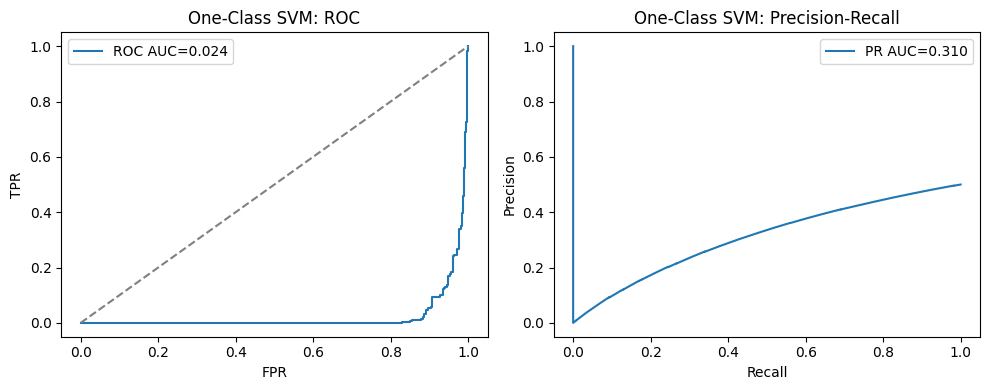

Saved: C:\EIE4121_Miniproject\results\oneclass_svm_curves.png


In [6]:
from pathlib import Path
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
 )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json

results_dir = Path("..") / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# --- Setup: train One-Class model on HUMAN only, evaluate anomaly detection on (human vs llm) ---
human_df = df_all[df_all["source"] == "human"].copy()
llm_df = df_all[df_all["source"] == "llm"].copy()

X_human = human_df["text"].fillna("").astype(str)
X_llm = llm_df["text"].fillna("").astype(str)

# Hold out some human for evaluation (to estimate false positives)
X_h_train, X_h_test = train_test_split(
    X_human, test_size=0.2, random_state=42
 )

# De-duplicate human training data by normalized text (reduces leakage from repeated templates)
def _normalize_text_simple(s: str) -> str:
    s = (s or "").lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

h_train_norm = X_h_train.apply(_normalize_text_simple)
dedup_mask = ~h_train_norm.duplicated(keep="first")
X_h_train_dedup = X_h_train[dedup_mask]

print("Human train size:", len(X_h_train), "-> dedup:", len(X_h_train_dedup))
print("Human test size:", len(X_h_test), "LLM pool size:", len(X_llm))

# Balanced evaluation set: all human test + same number of LLM samples
X_llm_eval = X_llm.sample(n=len(X_h_test), random_state=42, replace=False)
X_eval = pd.concat([X_h_test, X_llm_eval], axis=0)
y_eval_is_llm = np.array([0] * len(X_h_test) + [1] * len(X_llm_eval))  # 1 = anomaly target (llm)

# One-Class SVM pipeline: TF-IDF -> SVD -> scaling -> OneClassSVM
# Notes: SVD makes the data dense and lower-dimensional; scaling improves OneClassSVM stability.
ocsvm = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
        )),
        ("svd", TruncatedSVD(n_components=200, random_state=42)),
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)),
    ]
)

# Train on human-only data (normal)
ocsvm.fit(X_h_train_dedup)

# Scores: higher decision_function = more "inlier" (human-like). We'll flip sign so higher = more anomalous (LLM-like).
inlier_score = ocsvm.decision_function(X_eval)
anom_score = -inlier_score

# Default OCSVM predictions: +1 inlier, -1 outlier
pred_inlier = ocsvm.predict(X_eval)
y_pred_is_llm = (pred_inlier == -1).astype(int)

# Metrics for anomaly detection viewed as binary classification (LLM=positive)
metrics = {
    "accuracy": float(accuracy_score(y_eval_is_llm, y_pred_is_llm)),
    "precision": float(precision_score(y_eval_is_llm, y_pred_is_llm, zero_division=0)),
    "recall": float(recall_score(y_eval_is_llm, y_pred_is_llm, zero_division=0)),
    "f1": float(f1_score(y_eval_is_llm, y_pred_is_llm, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_eval_is_llm, anom_score)),
    "avg_precision": float(average_precision_score(y_eval_is_llm, anom_score)),
    "human_train_size": int(len(X_h_train)),
    "human_train_dedup_size": int(len(X_h_train_dedup)),
    "human_test_size": int(len(X_h_test)),
    "llm_eval_size": int(len(X_llm_eval)),
    "nu": 0.05,
    "svd_components": 200,
}

print("\n[one-class-svm anomaly detection] metrics:")
for k, v in metrics.items():
    print(k, v)

cm = confusion_matrix(y_eval_is_llm, y_pred_is_llm)
print("\nConfusion matrix (rows=true [human,llm], cols=pred [human,llm]):\n", cm)

# Save metrics
out = {"one_class_svm": metrics, "confusion_matrix": cm.tolist()}
out_path = results_dir / "oneclass_svm_metrics.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2)
print("Saved:", out_path.resolve())

# Optional: save ROC + PR curves for the report
fpr, tpr, _ = roc_curve(y_eval_is_llm, anom_score)
prec, rec, _ = precision_recall_curve(y_eval_is_llm, anom_score)
roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("One-Class SVM: ROC")
axes[0].legend()

axes[1].plot(rec, prec, label=f"PR AUC={pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("One-Class SVM: Precision-Recall")
axes[1].legend()

plt.tight_layout()
fig_path = results_dir / "oneclass_svm_curves.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path.resolve())

## Method 3 salvage: make one-class viable?
We try a quick salvage pass to see whether anomaly detection can work better with different settings/models.

We test:
- One-Class SVM with a small sweep over `nu`
- Isolation Forest on the same TF‑IDF+SVD embedding
- Isolation Forest / One-Class SVM on simple stylometric/structure features (`df_feat`) instead of TF‑IDF


In [8]:
from __future__ import annotations

from pathlib import Path
import json
from typing import Optional
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
 )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

results_dir = Path("..") / "results"
results_dir.mkdir(parents=True, exist_ok=True)

def _eval_anomaly(
    y_true_is_llm: np.ndarray,
    y_pred_is_llm: np.ndarray,
    score_is_llm: Optional[np.ndarray],
) -> dict:
    out = {
        "accuracy": float(accuracy_score(y_true_is_llm, y_pred_is_llm)),
        "precision": float(precision_score(y_true_is_llm, y_pred_is_llm, zero_division=0)),
        "recall": float(recall_score(y_true_is_llm, y_pred_is_llm, zero_division=0)),
        "f1": float(f1_score(y_true_is_llm, y_pred_is_llm, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true_is_llm, y_pred_is_llm).tolist(),
    }
    if score_is_llm is not None:
        out["roc_auc"] = float(roc_auc_score(y_true_is_llm, score_is_llm))
        out["avg_precision"] = float(average_precision_score(y_true_is_llm, score_is_llm))
    return out

def _add_eda_features_local(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    txt = df["text"].fillna("").astype(str)
    df["char_len"] = txt.str.len()
    df["word_count"] = txt.str.split().apply(len)
    df["avg_word_len"] = txt.apply(lambda s: (sum(len(w) for w in s.split()) / max(len(s.split()), 1)))
    df["exclaim_count"] = txt.str.count("!")
    df["question_count"] = txt.str.count("\\?")
    df["ttr"] = txt.apply(lambda s: (len(set(s.lower().split())) / max(len(s.split()), 1)))
    return df

# Reuse the same eval set as Method 3 (human held-out vs sampled LLM) for apples-to-apples
X_eval_text = X_eval.copy()
y_eval_is_llm_local = y_eval_is_llm.copy()

salvage = {"text_space": {}, "stylometry_space": {}}

# ---- A) Text-space models (TF-IDF -> SVD -> scaling) ----
tfidf_cfg = dict(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

embedder = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(**tfidf_cfg)),
        ("svd", TruncatedSVD(n_components=200, random_state=42)),
        ("scaler", StandardScaler()),
    ]
)

Z_train = embedder.fit_transform(X_h_train_dedup)
Z_eval = embedder.transform(X_eval_text)

# A1) One-Class SVM sweep
for nu in [0.01, 0.03, 0.05, 0.1, 0.2]:
    m = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    m.fit(Z_train)
    pred_inlier = m.predict(Z_eval)  # +1 inlier, -1 outlier
    y_pred = (pred_inlier == -1).astype(int)
    score = -m.decision_function(Z_eval)  # higher = more LLM-like
    key = f"ocsvm_nu_{nu}"
    salvage["text_space"][key] = _eval_anomaly(y_eval_is_llm_local, y_pred, score)
    salvage["text_space"][key]["nu"] = nu

# A2) Isolation Forest sweep
for cont in ["auto", 0.05, 0.1, 0.2]:
    iso = IsolationForest(
        n_estimators=500,
        random_state=42,
        contamination=cont,
    )
    iso.fit(Z_train)
    pred_inlier = iso.predict(Z_eval)  # +1 inlier, -1 outlier
    y_pred = (pred_inlier == -1).astype(int)
    score = -iso.decision_function(Z_eval)
    key = f"isoforest_cont_{cont}"
    salvage["text_space"][key] = _eval_anomaly(y_eval_is_llm_local, y_pred, score)
    salvage["text_space"][key]["contamination"] = cont

# ---- B) Stylometry/structure-space models (numeric features) ----
df_feat_local = _add_eda_features_local(df_all)
feat_cols = ["char_len", "word_count", "avg_word_len", "ttr", "exclaim_count", "question_count", "url_count"]
df_num = df_feat_local[feat_cols].copy()

# Stabilize heavy-tailed counts (log1p)
for col in ["char_len", "word_count", "exclaim_count", "question_count", "url_count"]:
    df_num[col] = np.log1p(df_num[col])

# Define our own index-level split (fixed seed), to avoid relying on earlier executed EDA cells
human_idx = human_df.index.to_numpy()
llm_idx = llm_df.index.to_numpy()
human_idx_train, human_idx_test = train_test_split(human_idx, test_size=0.2, random_state=42)

# De-duplicate the human train set by normalized text
human_train_text_norm = (
    df_all.loc[human_idx_train, "text"]
    .fillna("")
.astype(str)
.apply(_normalize_text_simple)
)
dedup_idx_mask = ~human_train_text_norm.duplicated(keep="first")
human_idx_train_dedup = human_idx_train[dedup_idx_mask.values]

# Balanced eval: human test vs sampled LLM
rng = np.random.default_rng(42)
llm_idx_eval = rng.choice(llm_idx, size=len(human_idx_test), replace=False)
idx_eval = np.concatenate([human_idx_test, llm_idx_eval])
y_eval2 = np.array([0] * len(human_idx_test) + [1] * len(llm_idx_eval))

Z2_train = df_num.loc[human_idx_train_dedup].to_numpy()
Z2_eval = df_num.loc[idx_eval].to_numpy()

scaler2 = StandardScaler()
Z2_train_s = scaler2.fit_transform(Z2_train)
Z2_eval_s = scaler2.transform(Z2_eval)

# B1) Isolation Forest on numeric features
for cont in ["auto", 0.05, 0.1, 0.2]:
    iso2 = IsolationForest(n_estimators=500, random_state=42, contamination=cont)
    iso2.fit(Z2_train_s)
    pred_inlier = iso2.predict(Z2_eval_s)
    y_pred = (pred_inlier == -1).astype(int)
    score = -iso2.decision_function(Z2_eval_s)
    key = f"isoforest_cont_{cont}"
    salvage["stylometry_space"][key] = _eval_anomaly(y_eval2, y_pred, score)
    salvage["stylometry_space"][key]["contamination"] = cont

# B2) One-Class SVM on numeric features
for nu in [0.01, 0.03, 0.05, 0.1, 0.2]:
    oc2 = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    oc2.fit(Z2_train_s)
    pred_inlier = oc2.predict(Z2_eval_s)
    y_pred = (pred_inlier == -1).astype(int)
    score = -oc2.decision_function(Z2_eval_s)
    key = f"ocsvm_nu_{nu}"
    salvage["stylometry_space"][key] = _eval_anomaly(y_eval2, y_pred, score)
    salvage["stylometry_space"][key]["nu"] = nu

def _best_by(space: dict, metric: str):
    best = None
    for k, v in space.items():
        if metric not in v:
            continue
        if best is None or v[metric] > best[1]:
            best = (k, v[metric], v)
    return best

print("\n[text_space] best by ROC AUC:", _best_by(salvage["text_space"], "roc_auc"))
print("[text_space] best by AP:", _best_by(salvage["text_space"], "avg_precision"))
print("\n[stylometry_space] best by ROC AUC:", _best_by(salvage["stylometry_space"], "roc_auc"))
print("[stylometry_space] best by AP:", _best_by(salvage["stylometry_space"], "avg_precision"))

out_path = results_dir / "oneclass_salvage_metrics.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(salvage, f, indent=2)
print("\nSaved:", out_path.resolve())


[text_space] best by ROC AUC: ('isoforest_cont_auto', 0.03504999999999998, {'accuracy': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'confusion_matrix': [[400, 0], [400, 0]], 'roc_auc': 0.03504999999999998, 'avg_precision': 0.3117546422045618, 'contamination': 'auto'})
[text_space] best by AP: ('isoforest_cont_auto', 0.3117546422045618, {'accuracy': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'confusion_matrix': [[400, 0], [400, 0]], 'roc_auc': 0.03504999999999998, 'avg_precision': 0.3117546422045618, 'contamination': 'auto'})

[stylometry_space] best by ROC AUC: ('ocsvm_nu_0.05', 0.4348375, {'accuracy': 0.46625, 'precision': 0.18604651162790697, 'recall': 0.02, 'f1': 0.03611738148984198, 'confusion_matrix': [[365, 35], [392, 8]], 'roc_auc': 0.4348375, 'avg_precision': 0.42307945032784205, 'nu': 0.05})
[stylometry_space] best by AP: ('ocsvm_nu_0.05', 0.42307945032784205, {'accuracy': 0.46625, 'precision': 0.18604651162790697, 'recall': 0.02, 'f1': 0.03611738148984198, 'confus

### Salvage outcome (summary)
- **Text-space (TF‑IDF + SVD)**: sweeping `nu` and switching to Isolation Forest still yields **LLM recall = 0** and very low ROC AUC (≈ 0.02–0.04).
- **Stylometry/structure features**: One‑Class SVM does slightly better, but still weak (best run: **LLM recall = 0.02**, ROC AUC ≈ 0.435).
- Conclusion: in this dataset, **LLM emails are not outliers** relative to human emails under these feature spaces, so one-class novelty detection is not a reliable detector here.

Saved full sweep results to `results/oneclass_salvage_metrics.json`.

## Method update: dimensionality control, nonlinear SVM, and autoencoder anomaly detection

This section addresses reviewer concerns directly:

- keep the primary task as **binary human vs LLM classification**
- evaluate **TF-IDF dimensionality control** (chi-square selection and SVD)
- test a **nonlinear supervised boundary** (RBF SVM on reduced features)
- add an **autoencoder-style anomaly detector** trained on human-only data

New artifacts saved by this section:

- `results/method_comparison_extended.json`
- `results/autoencoder_anomaly_metrics.json`

In [2]:
from time import perf_counter
from pathlib import Path
import json
import numpy as np
import pandas as pd

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

results_dir = Path("..") / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Ensure primary task variables are present even if this cell is run independently.
X_ext = df_all["text"].fillna("").astype(str)
y_ext = df_all["is_llm"].astype(int)

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext,
    y_ext,
    test_size=0.2,
    random_state=42,
    stratify=y_ext,
)

def _binary_metrics(y_true, y_pred, y_score=None):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_score is not None:
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
        out["avg_precision"] = float(average_precision_score(y_true, y_score))
    return out

# -----------------------------
# A) Supervised method variants
# -----------------------------
tfidf_base = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

Xtr_tfidf = tfidf_base.fit_transform(X_train_ext)
Xte_tfidf = tfidf_base.transform(X_test_ext)
n_features = int(Xtr_tfidf.shape[1])

k_chi2 = int(min(20000, max(100, n_features // 2)))
svd_dim = int(min(300, max(2, n_features - 1)))

extended_results = {
    "metadata": {
        "n_train": int(Xtr_tfidf.shape[0]),
        "n_test": int(Xte_tfidf.shape[0]),
        "tfidf_features": n_features,
        "k_chi2": k_chi2,
        "svd_dim": svd_dim,
    },
    "models": {},
}

# A1) Baseline LogReg on full TF-IDF
start = perf_counter()
logreg_full = LogisticRegression(max_iter=2000)
logreg_full.fit(Xtr_tfidf, y_train_ext)
fit_time = perf_counter() - start

start = perf_counter()
y_pred = logreg_full.predict(Xte_tfidf)
if hasattr(logreg_full, "decision_function"):
    y_score = logreg_full.decision_function(Xte_tfidf)
else:
    y_score = logreg_full.predict_proba(Xte_tfidf)[:, 1]
pred_time = perf_counter() - start

extended_results["models"]["tfidf_logreg_full"] = {
    **_binary_metrics(y_test_ext, y_pred, y_score),
    "fit_seconds": float(fit_time),
    "predict_seconds": float(pred_time),
    "effective_dim": n_features,
}

# A2) TF-IDF + chi2 + LogReg
selector = SelectKBest(score_func=chi2, k=k_chi2)
Xtr_chi2 = selector.fit_transform(Xtr_tfidf, y_train_ext)
Xte_chi2 = selector.transform(Xte_tfidf)

start = perf_counter()
logreg_chi2 = LogisticRegression(max_iter=2000)
logreg_chi2.fit(Xtr_chi2, y_train_ext)
fit_time = perf_counter() - start

start = perf_counter()
y_pred = logreg_chi2.predict(Xte_chi2)
if hasattr(logreg_chi2, "decision_function"):
    y_score = logreg_chi2.decision_function(Xte_chi2)
else:
    y_score = logreg_chi2.predict_proba(Xte_chi2)[:, 1]
pred_time = perf_counter() - start

extended_results["models"]["tfidf_chi2_logreg"] = {
    **_binary_metrics(y_test_ext, y_pred, y_score),
    "fit_seconds": float(fit_time),
    "predict_seconds": float(pred_time),
    "effective_dim": int(Xtr_chi2.shape[1]),
}

# A3) TF-IDF + SVD + LogReg
svd_lr = TruncatedSVD(n_components=svd_dim, random_state=42)
Xtr_svd = svd_lr.fit_transform(Xtr_tfidf)
Xte_svd = svd_lr.transform(Xte_tfidf)

start = perf_counter()
logreg_svd = LogisticRegression(max_iter=2000)
logreg_svd.fit(Xtr_svd, y_train_ext)
fit_time = perf_counter() - start

start = perf_counter()
y_pred = logreg_svd.predict(Xte_svd)
if hasattr(logreg_svd, "decision_function"):
    y_score = logreg_svd.decision_function(Xte_svd)
else:
    y_score = logreg_svd.predict_proba(Xte_svd)[:, 1]
pred_time = perf_counter() - start

extended_results["models"]["tfidf_svd_logreg"] = {
    **_binary_metrics(y_test_ext, y_pred, y_score),
    "fit_seconds": float(fit_time),
    "predict_seconds": float(pred_time),
    "effective_dim": int(Xtr_svd.shape[1]),
}

# A4) TF-IDF + SVD + RBF SVM (nonlinear check)
start = perf_counter()
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf.fit(Xtr_svd, y_train_ext)
fit_time = perf_counter() - start

start = perf_counter()
y_pred = svm_rbf.predict(Xte_svd)
y_score = svm_rbf.decision_function(Xte_svd)
pred_time = perf_counter() - start

extended_results["models"]["tfidf_svd_rbf_svm"] = {
    **_binary_metrics(y_test_ext, y_pred, y_score),
    "fit_seconds": float(fit_time),
    "predict_seconds": float(pred_time),
    "effective_dim": int(Xtr_svd.shape[1]),
}

method_out_path = results_dir / "method_comparison_extended.json"
with open(method_out_path, "w", encoding="utf-8") as f:
    json.dump(extended_results, f, indent=2)

print("Saved:", method_out_path.resolve())
print("\nExtended supervised method summary:")
for name, vals in extended_results["models"].items():
    print(name, {k: vals[k] for k in ["accuracy", "precision", "recall", "f1", "effective_dim"]})

# -----------------------------------
# B) Autoencoder anomaly formulation
# -----------------------------------
human_text = df_all[df_all["source"] == "human"]["text"].fillna("").astype(str)
llm_text = df_all[df_all["source"] == "llm"]["text"].fillna("").astype(str)

X_h_train_full, X_h_test = train_test_split(human_text, test_size=0.2, random_state=42)
X_h_train, X_h_val = train_test_split(X_h_train_full, test_size=0.2, random_state=42)

# Balanced eval set: held-out human vs equal-size LLM sample
X_llm_eval = llm_text.sample(n=len(X_h_test), random_state=42, replace=False)
X_eval = pd.concat([X_h_test, X_llm_eval], axis=0)
y_eval_is_llm = np.array([0] * len(X_h_test) + [1] * len(X_llm_eval))

ae_vec = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=20000,
)

Z_h_train_sparse = ae_vec.fit_transform(X_h_train)
Z_h_val_sparse = ae_vec.transform(X_h_val)
Z_eval_sparse = ae_vec.transform(X_eval)

ae_svd_dim = int(min(128, max(2, Z_h_train_sparse.shape[1] - 1)))
ae_svd = TruncatedSVD(n_components=ae_svd_dim, random_state=42)

Z_h_train = ae_svd.fit_transform(Z_h_train_sparse)
Z_h_val = ae_svd.transform(Z_h_val_sparse)
Z_eval = ae_svd.transform(Z_eval_sparse)

scaler = StandardScaler()
Z_h_train_s = scaler.fit_transform(Z_h_train)
Z_h_val_s = scaler.transform(Z_h_val)
Z_eval_s = scaler.transform(Z_eval)

ae = MLPRegressor(
    hidden_layer_sizes=(128, 64, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    random_state=42,
)

ae.fit(Z_h_train_s, Z_h_train_s)

val_recon = ae.predict(Z_h_val_s)
val_err = np.mean((Z_h_val_s - val_recon) ** 2, axis=1)

eval_recon = ae.predict(Z_eval_s)
eval_err = np.mean((Z_eval_s - eval_recon) ** 2, axis=1)

thresholds = {
    "q95": float(np.quantile(val_err, 0.95)),
    "q99": float(np.quantile(val_err, 0.99)),
}

ae_results = {
    "metadata": {
        "human_train": int(len(X_h_train)),
        "human_val": int(len(X_h_val)),
        "human_test": int(len(X_h_test)),
        "llm_eval": int(len(X_llm_eval)),
        "tfidf_features": int(Z_h_train_sparse.shape[1]),
        "svd_dim": int(ae_svd_dim),
    },
    "thresholds": thresholds,
    "by_threshold": {},
    "score_metrics": {
        "roc_auc": float(roc_auc_score(y_eval_is_llm, eval_err)),
        "avg_precision": float(average_precision_score(y_eval_is_llm, eval_err)),
    },
}

for tag, thr in thresholds.items():
    y_pred_is_llm = (eval_err > thr).astype(int)
    ae_results["by_threshold"][tag] = _binary_metrics(y_eval_is_llm, y_pred_is_llm)

ae_out_path = results_dir / "autoencoder_anomaly_metrics.json"
with open(ae_out_path, "w", encoding="utf-8") as f:
    json.dump(ae_results, f, indent=2)

print("\nSaved:", ae_out_path.resolve())
print("Autoencoder anomaly summary:")
print(ae_results)

Saved: C:\EIE4121_Miniproject\results\method_comparison_extended.json

Extended supervised method summary:
tfidf_logreg_full {'accuracy': 0.99875, 'precision': 1.0, 'recall': 0.9975, 'f1': 0.9987484355444305, 'effective_dim': 92827}
tfidf_chi2_logreg {'accuracy': 0.99875, 'precision': 1.0, 'recall': 0.9975, 'f1': 0.9987484355444305, 'effective_dim': 20000}
tfidf_svd_logreg {'accuracy': 0.9975, 'precision': 0.9975, 'recall': 0.9975, 'f1': 0.9975, 'effective_dim': 300}
tfidf_svd_rbf_svm {'accuracy': 0.99875, 'precision': 0.9975062344139651, 'recall': 1.0, 'f1': 0.9987515605493134, 'effective_dim': 300}

Saved: C:\EIE4121_Miniproject\results\autoencoder_anomaly_metrics.json
Autoencoder anomaly summary:
{'metadata': {'human_train': 1280, 'human_val': 320, 'human_test': 400, 'llm_eval': 400, 'tfidf_features': 20000, 'svd_dim': 128}, 'thresholds': {'q95': 0.22382327601820023, 'q99': 0.3734984261210846}, 'by_threshold': {'q95': {'accuracy': 0.4775, 'precision': 0.125, 'recall': 0.0075, 'f1': 

c:\EIE4121_Miniproject\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Interpretation notes for report integration

- If reduced-dimension variants (chi2/SVD) match baseline performance, the result is likely not dependent on full vocabulary size.
- If RBF SVM does **not** materially outperform linear models, linear boundaries are sufficient for this dataset and preferable for efficiency.
- Autoencoder performance should be interpreted against false-positive tolerance and recall at chosen thresholds; weak performance implies LLM text is not strongly out-of-distribution under this representation.